# Introduction

There are few things I want to understand in this analysis so we can understand<br>
more about the data-field job market in LinkedIn, by inspecting jobs' requirements,<br>
salaries and other relevant info that might help us paint a clear picture about the<br>
current market of data-field jobs in LinkedIn.

> **NOTE**: Data-field refers to tech jobs that work mainly with data which are:
> - Data analysts 
> - Data engineers
> - Data scientests
> - Machine learning developers 

Things we are analysing in this notebook:
- [Q1](#q1). Pay types
- [Q2](#q2). Average salary
- [Q3](#q3). Frequent locations
- [Q4](#q4). Mentioned skills
- [Q5](#q5). Common industries
- [Q6](#q6). Required education
- [Q7](#q7). Seniority level

# Setting up

In [1]:
import time
import math
import duckdb
import sqlite3
import requests
import warnings
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import HTML
from pywaffle import Waffle # tasty

import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
import cartopy.feature as cfeature

from typing import List

DB_URI = "file:./data/clean_database.db?mode=ro"
CMAP = mpl.colors.LinearSegmentedColormap.from_list('custom', ["darkgreen", "PaleGreen"])
BAR_WIDTH = 0.7
FONT_PATH = "./fonts/Inter_24pt-Regular.ttf"

In [3]:
fm.fontManager.addfont(FONT_PATH)
prop = fm.FontProperties(fname=FONT_PATH)

mpl.rcParams['figure.dpi']  = 100
plt.rcParams['font.family'] = prop.get_name()

%matplotlib inline

In [4]:
with sqlite3.connect(DB_URI, uri=True) as con:
    linkedin_df = pd.read_sql_query("SELECT * FROM linkedin", con)

# Analysis

### Q1. Pay types <a id="q1"></a>

Firstly we are gonna see how common each pay type in the description is.<br>
pay type can have a one of the following values: annauly, hourly, or not-mentioned.<br>
This will help us know how common it is for companies to post thier salary and<br>
how common is hourly payment in data-field jobs

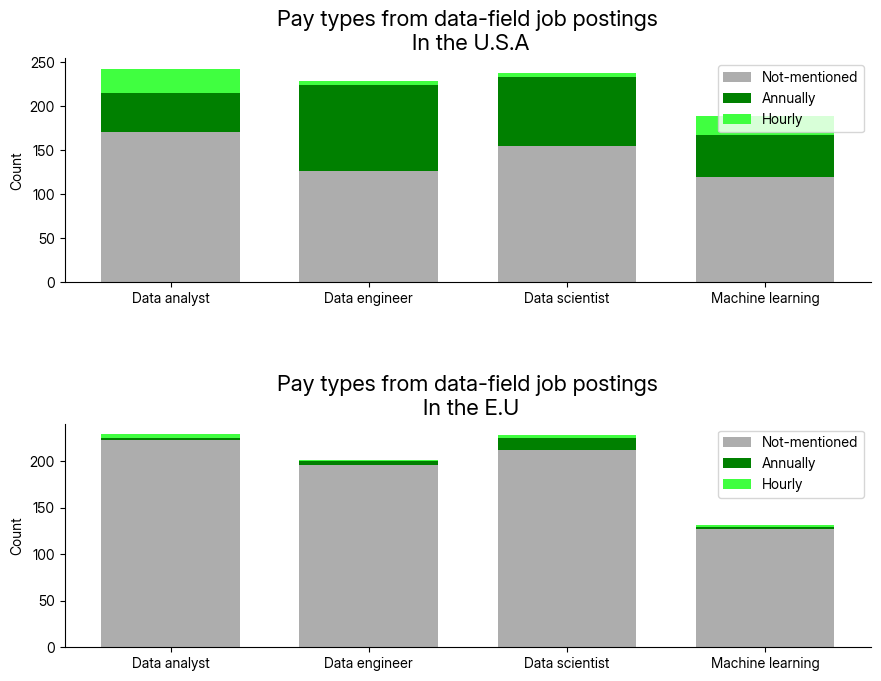

In [26]:
df = duckdb.sql("""
    SELECT 
        COUNT(id),
        SUM(CASE WHEN pay_type IS NULL THEN 1 ELSE 0 END) AS 'Not-mentioned',
        SUM(CASE WHEN pay_type = 'Annually' THEN 1 ELSE 0 END) AS 'Annually',
        SUM(CASE WHEN pay_type = 'Hourly' THEN 1 ELSE 0 END) AS 'Hourly',
        searched_country,
        searched_job_title
    FROM linkedin_df
    GROUP BY searched_job_title, searched_country
    ORDER BY searched_job_title
    """).df()

fig, axes = plt.subplots(nrows=2)

for country, ax in zip(["United States", "European Union"],
                       axes):
    bottom = np.zeros(4)
    for column_name, color in zip(["Not-mentioned", "Annually", "Hourly"],
                                  ["#ADADAD", "green", "#40ff40"]):
        # ["#bfffbf", "#40ff40", "#00bf00", "#004000", "#a9a9a9"]
        ax.bar(
            df[df["searched_country"] == country]["searched_job_title"],
            df[df["searched_country"] == country][column_name],
            BAR_WIDTH, bottom=bottom, label=column_name, color=color
        )
        bottom += df[df["searched_country"] == country][column_name]

    ax.legend(loc="upper right")
    
    ax.spines[['right', 'top']].set_visible(False)
    ax.set_ylabel("Count")

axes[0].grid(True, axis='y', linestyle='-', linewidth=0.8, color='grey', alpha=0.5)
axes[1].grid(True, axis='y', linestyle='-', linewidth=0.8, color='grey', alpha=0.5)

axes[0].set_title("Pay types from data-field job postings\n In the U.S.A", fontsize=16)
axes[1].set_title("Pay types from data-field job postings\n In the E.U", fontsize=16)

fig.set_size_inches(10, 8)
fig.tight_layout(pad=5.0)

plt.show()

Oh this wasn't expected, Most of the job postings don't include salary specially<br>
jobs postings in the E.U<br>

*(This might also be because that the salary extractor works best with English)<br>

This also means that we are not going to be able to analyse average salary in E.U<br>
job postings.<br>

We can also see that data engineers & scientists are paid annauly most of the time,<br>
On the other hand we can see that data analysts and machine learning devs payment can<br>
be hourly more often.

### Q2. Average salary <a id="q2"></a>

Let's now see the median of mentioned salaries for data-field jobs in the USA.<br><br>
**NOTE**: As seen in the previous question [Q1](#q1) most of the jobs doesn't mention salary at all and<br>
those who do isn't always annaul **SO** the result will only show the average salaries for jobs<br>
which mentions it in LinkedIn

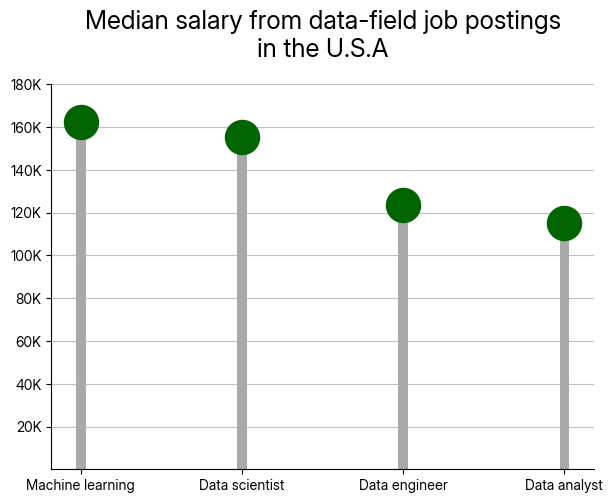

In [6]:
data = duckdb.sql("""
    SELECT
        COUNT(id) AS count,
        MEDIAN((salary_min + salary_max) / 2) AS salary,
        -- searched_country,
        searched_job_title
    FROM linkedin_df
    WHERE salary_min IS NOT NULL AND
        pay_type = 'Annually' AND
        searched_country = 'United States'
    GROUP BY searched_job_title
    HAVING count > 10
    ORDER BY salary DESC
""").df()


fig, ax = plt.subplots()


ax.bar(
    data["searched_job_title"], data["salary"], width=0.06, color="darkgrey",
)
ax.scatter(
    data["searched_job_title"], data["salary"], s=600, color="darkgreen"
)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    ax.set_yticklabels(['{:,.0f}'.format(x) + 'K' for x in ax.get_yticks()/1000])
    ax.spines[['right', 'top']].set_visible(False)
    
    ax.set_yticklabels(ax.get_yticklabels()[1:])  # Remove the first tick
    ax.set_yticks(ax.get_yticks()[1:])

ax.grid(True, axis='y', linestyle='-', linewidth=0.8, color='gray', alpha=0.5)
ax.set_axisbelow(True)

ax.set_title("Median salary from data-field job postings\nin the U.S.A", pad=20, fontsize=18)
fig.set_size_inches(7, 5)

plt.show()

We can see that all of those average salaries are really high compared to average salaries for<br>
the same jobs in the USA which makes senese because companies that offer high salaries<br>
are more likally to mention it in their job descriptions.

### Q3. Frequent locations <a id="q3"></a>

Now let us look at where data-jobs are most needed.

In [7]:
def get_cords(loc: str) -> list[float, float]:
    response = requests.get(
        f"https://nominatim.openstreetmap.org/search?q={loc}&format=json",
        headers={
            "User-Agent": "Analysis for Data-field jobs, Most common job locations in the U.S"
        })
    time.sleep(1) # respecting nominatim's usage policy
    json = response.json()
    if not json:
        return []
    return [float(json[0]["lon"]), float(json[0]["lat"])]

data = duckdb.sql("""
    SELECT location,
        COUNT(id) AS frequency
    FROM linkedin_df
    WHERE location <> 'United States' -- Don't retrieve remote jobs in the US
    GROUP BY location
""").df()

data["cords"] = data["location"].apply(get_cords)

In [ ]:
fig = plt.figure(figsize=(14, 7))

us_ax = plt.subplot(1, 2, 1, projection=ccrs.LambertConformal(),       )
eu_ax = plt.subplot(1, 2, 2, projection=ccrs.LambertConformal(20, 40), )

# both of the maps have the same longitude and latitude range though
# the map distortion doesn't make that clear
us_ax.set_extent([-120, -120+50, 20, 20+30], ccrs.Geodetic())
eu_ax.set_extent([-10, -10+50,   35, 35+30], ccrs.Geodetic())

us_shp = shpreader.natural_earth(
    resolution='110m',
    category='cultural',
    name="admin_1_states_provinces_lakes"
)

us_ax.add_geometries(
    shpreader.Reader(us_shp).geometries(),
    ccrs.PlateCarree(),
    styler=lambda g: {"facecolor": "white", "edgecolor": "black"})
us_ax.add_feature(cfeature.OCEAN, color='lightgrey')
us_ax.add_feature(cfeature.COASTLINE)

eu_ax.add_feature(cfeature.COASTLINE)
eu_ax.add_feature(cfeature.BORDERS, linewidth=1)
eu_ax.add_feature(cfeature.OCEAN, color='lightgrey')
eu_ax.set_title("* Only E.U countries are searched")

for ax in [us_ax, eu_ax]:
    for _, row in data.iterrows():
        if not row["cords"]:
            continue
    
        s = (math.log(row["frequency"]) if row["frequency"] != 1 else 0.5) * 10
        ax.plot(
            row["cords"][0], row["cords"][1], "o",
            markersize=s, c="darkgreen", alpha=0.5,
            transform=ccrs.Geodetic(),
        )

fig.suptitle("Distribution of data-field job locations\n in the E.U and the U.S", fontsize= 20)
fig.tight_layout()

plt.figtext(0.5, 0.01, "*Radius of the frequency circles is scaled logarithmically", ha="center",
            fontsize=13)

plt.show()

As expected big cities and tech companies areas such as Silicon Valley, NY require data-jobs<br>
a lot.<br>

What wasn't expected is that some eastren europe countries such as Poland and Romania also<br>
require a data-jobs a lot.

### Q4. Mentioned skills <a id="q4"></a>

What are the most mentioned skills in jobs descriptions for each data-field job title answering <br>
this question will show us the most important skills to have to apply to any of these data-field<br>
jobs.

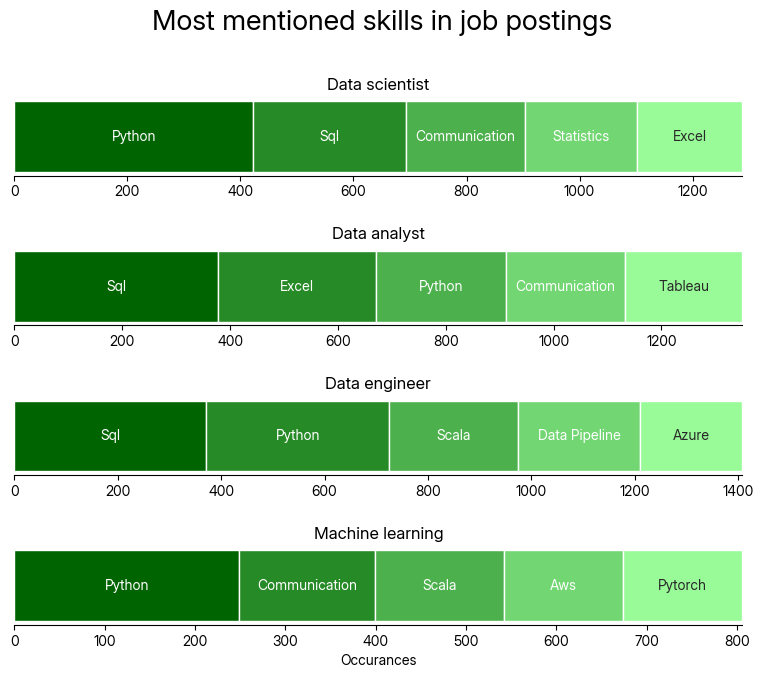

In [7]:
data = duckdb.sql("""
    SELECT * FROM (
        SELECT 
            skill, job_title,
            SUM(occurance) AS occurances, 
            ROW_NUMBER() OVER (PARTITION BY job_title ORDER BY occurances DESC) AS index
        FROM (
            SELECT 
                UNNEST(SPLIT(skills, ',')) AS skill,
                searched_job_title AS job_title,
                1 AS occurance
            FROM linkedin_df
        )
        GROUP BY skill, job_title
    )
    WHERE index <= 5
    ORDER BY occurances DESC
""").df()


fig, axes = plt.subplots(ncols= 1, nrows=len(data["job_title"].unique()))

for ax, job_title in zip(axes, data["job_title"].unique()):
    bar_start   = 0
    subdata = data[data["job_title"] == job_title]
    skills  = subdata["skill"].unique()
    colors  = CMAP(np.linspace(1, 0, len(skills)))
    
    ax.spines[['right', 'left', 'top']].set_visible(False)
    ax.yaxis.set_ticks([])
    
    for i, skill in enumerate(skills):
        width = subdata[subdata["skill"] == skill]["occurances"].iloc[0]
        color = colors[(len(skills)-1) - i]
        r, g, b, _ = color
        text_color = "white" if (r * g * b) < 0.3 else "#666666"
        
        bar = ax.barh(y=1,
                width=width,
                left=bar_start,
                edgecolor="white",
                color= color
        )
        ax.set_title(f"{job_title}")
        ax.bar_label(bar, label_type="center", labels=[skill.title()], color=text_color)
        ax.set_xlim(0, sum(subdata["occurances"]))
        bar_start += width

axes[3].set_xlabel("Occurances")

fig.suptitle('Most mentioned skills in job postings', fontsize=20)
fig.set_size_inches(8, 7)
fig.tight_layout(pad=2.0)
plt.show()

Sorry if the chart look kind of misleading but this is the most suitable chart type I found, anyway<br>
as I expected SQL and Python the most requested.<br>

Also we can see that communication is frequently requested which makes sense also.

### Q5. Common industries <a id="q5"></a>

Looking at which industries employ data-field jobs the most will let us know what background<br>
knowledge can be valuable when applying to a data-field job.

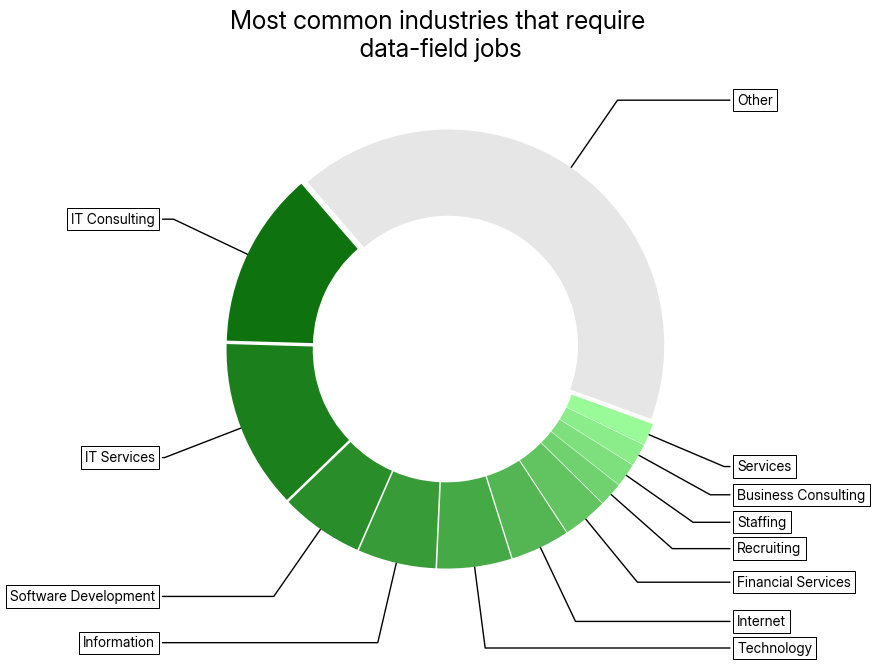

In [9]:
data = duckdb.sql("""
    WITH industry_counts AS (
        SELECT 
            TRIM(industry) AS industry,
            COUNT(*) AS occurances
        FROM (
            SELECT UNNEST(STRING_SPLIT_REGEX(industries, ',| and ')) AS industry
            FROM linkedin_df
        )
        GROUP BY industry
    ),
    
    ranked AS (
        SELECT 
            industry,
            occurances,
            ROW_NUMBER() OVER (ORDER BY occurances DESC) AS rank
        FROM industry_counts
    )
    
    SELECT 
        CASE WHEN rank > 12 THEN 'Other' ELSE industry END AS industry,
        SUM(occurances) AS occurances
    FROM ranked
    GROUP BY CASE WHEN rank > 12 THEN 'Other' ELSE industry END -- industry
    HAVING industry <> '' AND industry IS NOT NULL
    ORDER BY occurances DESC
""").df()

fig, ax = plt.subplots()

colors = list(CMAP(np.linspace(0, 1, len(data))))
colors[0] = np.array([0.90, 0.90, 0.90, 1])

wedges, texts = ax.pie(data["occurances"],
                       wedgeprops=dict(width=0.4),
                       startangle=-20,
                       colors= colors,
                       explode=np.linspace(0.02,0.02,len(data))
)

# Thanks for: https://matplotlib.org/stable/gallery/pie_and_polar_charts/pie_and_donut_labels.html 
bbox_props = dict(boxstyle="square,pad=0.3", fc="w", ec="k", lw=0.72)
kw = dict(arrowprops=dict(arrowstyle="-"),
          bbox=bbox_props, zorder=0, va="center")

for i, p in enumerate(wedges):
    ang = (p.theta2 - p.theta1)/2. + p.theta1
    y = np.sin(np.deg2rad(ang))
    x = np.cos(np.deg2rad(ang))
    horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
    connectionstyle = f"angle,angleA=0,angleB={ang}"
    kw["arrowprops"].update({"connectionstyle": connectionstyle})
    
    ax.annotate(data["industry"].iloc[i], xy=(x, y), xytext=(1.35*np.sign(x), 1.4*y),
                horizontalalignment=horizontalalignment, **kw)

fig.suptitle("Most common industries that require\n data-field jobs", fontsize=18)
fig.set_size_inches(7, 7)
plt.show()

Looks like most of these industries are tech related so it might be useful to have background<br>
I.T or software development, other industries that require data-field jobs are side jobs such<br>
as recruiting and financial stuff.

### Q6. Required education <a id="q6"></a>

What's the most required degree that data-field jobs ask for, This is the question I am most<br>
curious to answer, It'll help us see how much do companies care for a candidate to have a<br>
degree

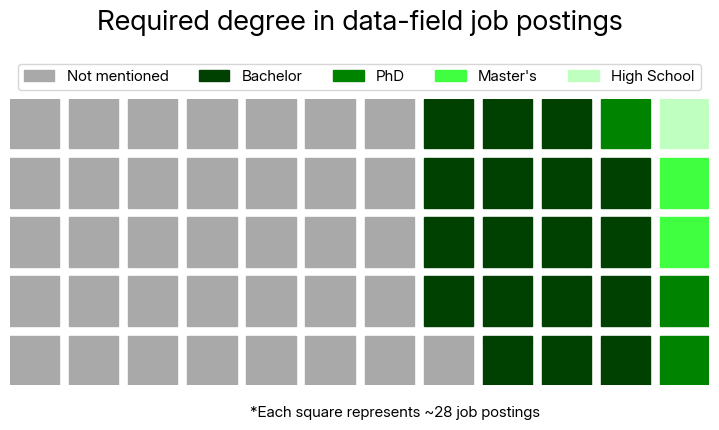

In [10]:
data = duckdb.sql("""
    SELECT education, COUNT(*) AS occurances
    FROM linkedin_df
    GROUP BY education
    ORDER BY occurances DESC
""").df()

data_dict: dict = data.set_index("education").T.to_dict("records")[0]

colors = ["#A9A9A9", "#004000", "#008400", "#40ff40", "#bfffbf"]

ROWS = 5
COLS = 12

fig = plt.figure(
    FigureClass=Waffle,
    rows=ROWS,
    columns=COLS,
    values=data_dict,
    colors=colors,
    legend={
        'loc': 'upper left',
        'bbox_to_anchor': (0, 1.15), # position of the legend
        'ncol': len(data), # number of columns in the legend
        'fontsize': 11 #size of the legend
    }
)

plt.figtext(0.5, 0.25,
            f"*Each square represents ~{data["occurances"].sum() // (ROWS*COLS)} job postings",
            ha="center", fontsize=11)

plt.title("Required degree in data-field job postings", pad=50, fontdict={"fontsize":20})

fig.set_size_inches(w=8, h=7)
plt.show()

Wow that surprising that more than 50% of the jobs didn't even mention a degree in thier job<br>
description.

### Q7. Seniority level <a id="q7"></a>

Finally let's look at what's the most requested seniority levels by data-field jobs<br>
which will help us see what data-field job is the most open to newcomers.

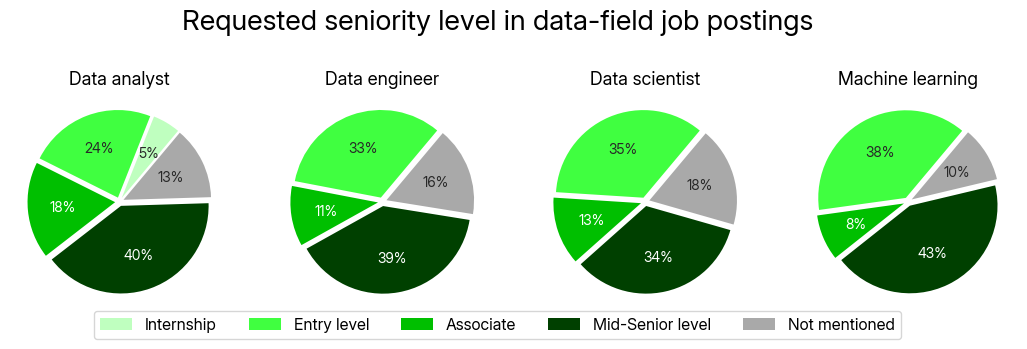

In [14]:
data = duckdb.sql("""
    SELECT 
        COUNT(*) AS occurances,
        CASE WHEN seniority_level IS NULL THEN 'Not mentioned' ELSE seniority_level END AS seniority_level,
        searched_job_title AS job_title
    FROM linkedin_df
    GROUP BY seniority_level, searched_job_title 
    HAVING occurances > 20
    ORDER BY searched_job_title, 
        CASE seniority_level
            WHEN 'Not mentioned' THEN 1
            WHEN 'Internship' THEN 2
            WHEN 'Entry level' THEN 3
            WHEN 'Associate' THEN 4
            WHEN 'Mid-Senior level' THEN 5
            ELSE 6
        END
""").df()

ncols = len(data["job_title"].unique())
colors = ["#bfffbf", "#40ff40", "#00bf00", "#004000", "#a9a9a9"]

fig, axes = plt.subplots(nrows=1, ncols=ncols)

for i, job_title in enumerate(data["job_title"].unique()):
    job_title_data = data[data["job_title"] == job_title]

    if len(job_title_data) != len(colors):
        colors = colors[len(colors) - len(job_title_data):]

    _, _, autotexts = axes[i].pie(job_title_data["occurances"],
                #wedgeprops=dict(width=0.8),
                colors=colors, autopct='%1.0f%%', 
                textprops={'color': text_color},
                startangle=50,
                explode=[0.05]*len(job_title_data)
           )
    axes[i].set_title(f"{job_title}", fontsize=13)

    for j, autotext in enumerate(autotexts):
        r, g, b = mpl.colors.to_rgb(colors[j])
        brightness = 0.299 * r + 0.587 * g + 0.114 * b
        text_color = "#ffffff" if brightness < 0.5 else "#282828"
        autotext.set_color(text_color)

fig.suptitle("Requested seniority level in data-field job postings", fontsize= 20, y=0.77)
plt.figlegend(data["seniority_level"].unique(), loc="upper center",
              ncols=len(data["seniority_level"].unique()),
              bbox_to_anchor=(0.5, 0.35), fontsize=11.5)

fig.set_size_inches(13, 7)
plt.show()

We can see that Machine learning jobs are the most open to juniors and seniors in the same time,<br>
this might also be due it's the job with the least amount of N/A values in the seniority level.

But -surprisingly- data analyst jobs are the least open to Entry level though some of them offers<br>
internships.

# Summary

Thanks 😊 for looking into my humble analysis for the data-field job market<br>
hope you found it informative here's a summary of all of the findings:

- Q1. Pay Types:<br>
Most job postings do not mention salary, especially in Europe. When salaries are listed,<br>
data engineers and scientists are usually paid annually, while analyst and ML roles more<br>
often mention hourly rates.

- Q2. Average Salary (USA):<br>
The median salaries shown are high, likely because only companies offering competitive<br>
pay choose to include salaries in job descriptions—so the results are biased toward <br>
higher-paying roles.


- Q3. Frequent Locations:<br>
Major tech hubs like Silicon Valley and New York dominate demand for data roles, but<br>
unexpectedly high demand was also seen in Eastern European countries such as Poland and<br>
Romania.

- Q4. Most Mentioned Skills:<br>
SQL and Python are the top required skills across all data roles, with communication<br>
skills also appearing frequently.

- Q5. Common Industries:<br>
Most opportunities come from tech-related industries, followed by fields like finance<br>
and recruiting, suggesting that an IT or software background is especially valuable.

- Q6. Required Education:<br>
Over 50% of postings do not specify a degree requirement, indicating that many companies<br>
are flexible about formal education, relying instead on skills and experience.

- Q7. Seniority Levels:<br>
Machine learning roles show strong demand for both junior and senior levels. Data analyst<br>
roles, however, are less open to entry-level candidates, despite some internship availability.